In [1]:
from calculos_plasmas import *
import matplotlib.pyplot as plt

def analizar_autovalores(plasma : Plasma, titulo="Comparación de Autovalores"):
    """
    Compara las energías numéricas de un objeto Plasma con las analíticas del hidrógeno.
    """
    if plasma.E_0 is None:
        raise ValueError("Todavía no se han computado los autovalores.")

    n_values = [1]
    E_num = [plasma.E_0]
    E_ana = [-0.5*E_h*plasma.Z**2]

    for l in range(1, len(plasma.E_l)):
        E_l = plasma.E_l[l]
        n_start = l + 1 if l > 0 else 2

        for i, E_nl in enumerate(E_l):
            n = n_start + i
            n_values.append(n)
            E_num.append(E_nl)
            E_ana.append(-0.5*E_h*plasma.Z**2 / n**2)

    n_values = np.array(n_values)
    E_num_eV = np.array(E_num) / E_h
    E_ana_eV = np.array(E_ana) / E_h

    mse_eV = np.mean((E_num_eV - E_ana_eV)**2)

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, E_ana_eV, 'kx', markersize=10, label='Analítico')
    plt.plot(n_values, E_num_eV, 'ro', alpha=0.7, label=f'Numérico')

    plt.title(f"{titulo}\nDistancia Cuadrática Media: {mse_eV:.2e} $eV^2$")
    plt.xlabel("Número cuántico principal ($n$)")
    plt.ylabel("Energía (eV)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    return mse_eV

Vamos a simular un plasma A sin cuyo potencial no considera efectos de plasma

In [2]:
A = Plasma()
A.set_temperature(1, "eV")
A.set_electron_density(1e22, "cm")
A.set_atomic_mesh(2e5)
A.max_radius = 500
A.n_max = 1
A.l_max = 0
A.solve_schrodinger(plasma_effects=True)
#A.solve_transitions()
A.solve_population(plasma_effects=True)
#A.solve_spectrum()

In [3]:
T = [1, 5, 1, 5, 1, 5]
n = [1e18, 1e18, 1e20, 1e20, 1e22, 1e22]
n_max = [10, 10, 5, 5, 1, 1]
C = []
for i in range(6):
    P = Plasma()
    P.set_temperature(T[i], 'eV')
    P.set_electron_density(n[i], "cm")
    P.n_max = n_max[i]
    P.l_max = n_max[i]-1
    P.solve_schrodinger()
    P.solve_population()
    C.append(P.n_H/P.n_P)
print(C)

[np.float64(206.32158079000027), np.float64(0.012418176555434417), np.float64(771.3758227029501), np.float64(0.18122505775116346), np.float64(3.7427783969924437), np.float64(0.5153232721711308)]


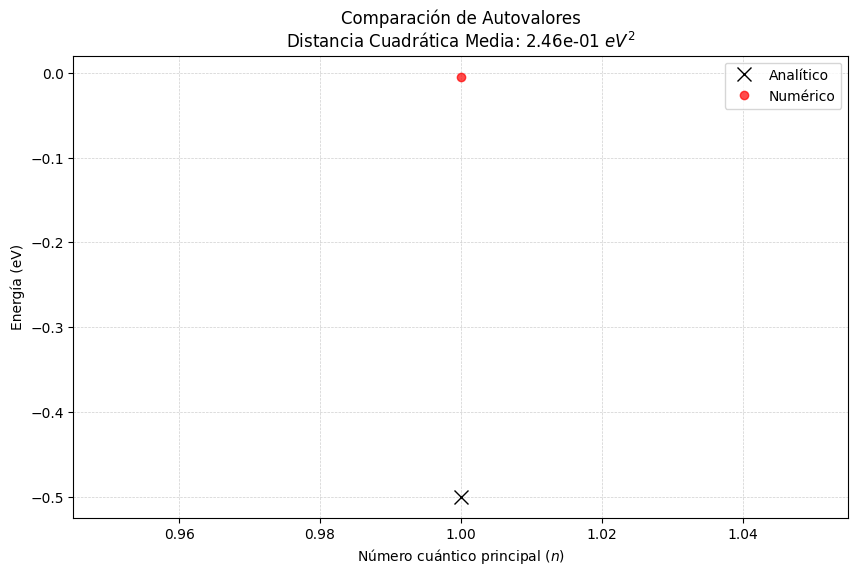

np.float64(0.2455357624040918)

In [4]:
analizar_autovalores(A)

Comprobemos ahora que hemos elegido correctamente el radio máximo

In [5]:
def plot_frontera(plasma, l, n):
    if A.n_max == 1 or len(A.E_l[l]+l+1) < n:
        raise ValueError("Error: En el plasma no existe el estado deseado")

    u = plasma.u_l[l]/E_h

    i = n - l - 1
    if i < 0 or i >= u.shape[1]:
        raise NameError(f"Error: El estado n={n} no existe físicamente para l={l} con los parámetros actuales.")

    u_nl = u[:, i]

    plt.figure(figsize=(8, 4))
    plt.plot(plasma.r, u_nl, label=f'Densidad $u(r)$ para $n={n}$')
    plt.axvline(100, color='red', linestyle='--', label='Radio clásico (100 u.a.)')

    plt.title(f'Comprobación de la frontera para $l={l}, n={n}$')
    plt.xlabel(r'$r$ (unidades atómicas)')
    plt.ylabel('Densidad de probabilidad')
    plt.xlim(0, plasma.max_radius)
    plt.grid(True)
    plt.legend()
    plt.show()


In [6]:
plot_frontera(A, 0, len(A.E_l[0]))

ValueError: Error: En el plasma no existe el estado deseado